# Wakefield: a spline cavity

The ABCI wakefield solver runs the bunch through the cavity and reports the wake potentials and the beam-coupling impedance, for any geometry through `cav.wakefield`. This notebook walks the full single-cavity plotting suite.

> Needs the bundled `ABCI.exe` (Windows) / `abci` on PATH; ABCI needs a beam pipe at **both** ends.

In [1]:
import os, tempfile
import matplotlib.pyplot as plt
from cavsim2d import SplineCavity
from cavsim2d.utils.style import apply_style
apply_style()

WF = {'MROT': 2, 'wakelength': 20, 'bunch_length': 25}   # long.+trans., 20 m, 25 mm

## The cavity

A Bezier spline with a **smooth iris** (`p1`, `p4` at the beam-pipe radius, so the wall leaves the pipe tangentially) and pipes at both ends.

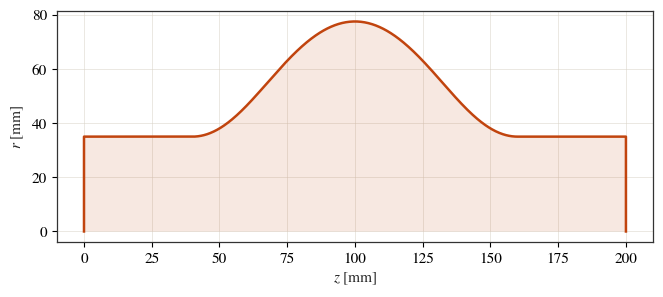

<Axes: xlabel='$z$ [mm]', ylabel='$r$ [mm]'>

In [2]:
geom = {'p0': [0, 35], 'p1': [30, 35], 'p2': [42, 103],
        'p3': [78, 103], 'p4': [90, 35], 'p5': [120, 35]}
spline = SplineCavity({'geometry': dict(geom), 'beampipe': 'both', 'beampipe_length': 40}, kind='Bezier')
spline.name = 'spline'
spline.set_workspace(os.path.join(tempfile.mkdtemp(), 'spline_wf'))
spline.plot('geometry')

In [3]:
spline.wakefield.run(WF)
spline.wakefield.qois

{'|k_loss| [V/pC]': 0.0762,
 'k_FM [V/pC]': 0.070104,
 'k_loss_HOM [V/pC]': 0.006096000000000004,
 '|k_kick| [V/pC/m]': 3.314}

## Impedance: longitudinal and transverse

`MROT=2` computed both polarisations. The longitudinal impedance drives the beam's energy spread; the transverse drives beam-breakup.

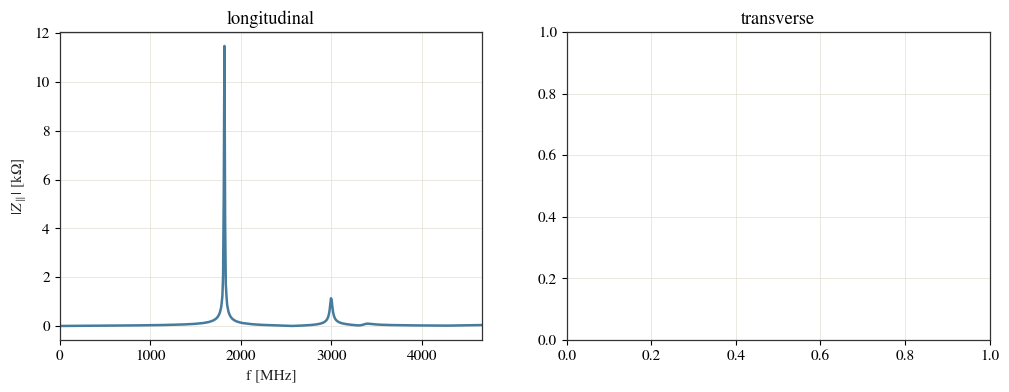

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
spline.wakefield.plot_impedance('longitudinal', ax=a1, show=False)
spline.wakefield.plot_impedance('transverse', ax=a2, show=False)
a1.set_title('longitudinal'); a2.set_title('transverse'); plt.show()

## Wake potential

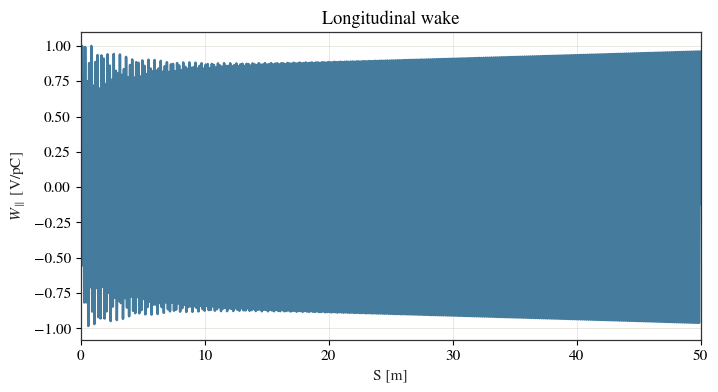

<Axes: title={'center': 'Longitudinal wake'}, xlabel='S [m]', ylabel='$W_\\parallel$ [V/pC]'>

In [5]:
spline.wakefield.plot_wake('longitudinal')

## Loss- and kick-factor spectra

The cumulative loss factor $k_\parallel(F)$ and kick factor $k_\perp(F)$ — how much of the wake is accumulated up to each frequency.

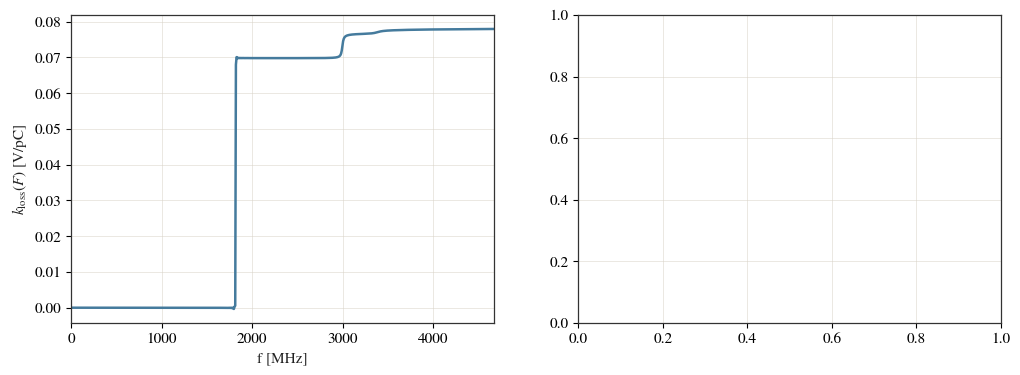

In [6]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
spline.wakefield.plot_k_loss(ax=a1, show=False)
spline.wakefield.plot_k_kick(ax=a2, show=False)
plt.show()

## Where to go next

- [Wakefield: an RF gun](rfgun.ipynb) · [a reentrant cavity](reentrant.ipynb) (with a field-line animation) · [varying a parameter](parameter_sweep.ipynb).
- [Wakefield and impedance](impedance.ipynb) — the elliptical TESLA cavity, with the eigenmode-reconstructed impedance overlaid.